# NYC Taxi Trip Duration Prediction 🚕 

<img src="https://s.wsj.net/public/resources/images/BN-UV587_NYTAXI_TOP_20170827152144.jpg" width="800">

## Project Overview & Objectives

The primary subject of this research is the analysis of urban mobility patterns within New York City’s taxi network. The project aims to understand the relationship between geographic coordinates and temporal data to predict how long a specific journey will take. The core objective is to identify the underlying factors—such as peak hours, vendor differences, and spatial density—that influence travel time in a complex metropolitan environment. By transforming raw pickup and dropoff data into predictable patterns, the project seeks to provide a data-driven approach to urban transit estimation, moving beyond simple distance calculations to account for the dynamic nature of city traffic.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
import optuna
import plotly.express as px

from datetime import datetime
import math

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

pd.set_option('display.max_columns', 55)
warnings.filterwarnings('ignore')

## Reading Dataset

In [2]:
!unzip -q /kaggle/input/competitions/nyc-taxi-trip-duration/train.zip -d /kaggle/working
!unzip -q /kaggle/input/competitions/nyc-taxi-trip-duration/test.zip -d /kaggle/working

In [3]:
train = pd.read_csv('/kaggle/working/train.csv')
test = pd.read_csv('/kaggle/working/test.csv')

In [4]:
train.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  object 
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  object 
 3   dropoff_datetime    1458644 non-null  object 
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  object 
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 122.4+ MB


In [6]:
df = pd.concat([train, test], axis=0).reset_index(drop=True)

## EDA

In [7]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455.0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663.0
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124.0
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429.0
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2083778 entries, 0 to 2083777
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   id                  object 
 1   vendor_id           int64  
 2   pickup_datetime     object 
 3   dropoff_datetime    object 
 4   passenger_count     int64  
 5   pickup_longitude    float64
 6   pickup_latitude     float64
 7   dropoff_longitude   float64
 8   dropoff_latitude    float64
 9   store_and_fwd_flag  object 
 10  trip_duration       float64
dtypes: float64(5), int64(2), object(4)
memory usage: 174.9+ MB


In [9]:
df.shape

(2083778, 11)

In [10]:
df.columns

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [11]:
df1 = df.drop(['id', 'dropoff_datetime','store_and_fwd_flag'], axis=1)
df1['pickup_datetime'] = pd.to_datetime(df1['pickup_datetime'])

## Feature Engineering

In [12]:
df1['hour'] = df1['pickup_datetime'].dt.hour
df1['day_of_week'] = df1['pickup_datetime'].dt.dayofweek 
df1['day_name'] = df1['pickup_datetime'].dt.day_name()   
df1['month'] = df1['pickup_datetime'].dt.month
df1['day'] = df1['pickup_datetime'].dt.day
df1['is_weekend'] = df1['pickup_datetime'].dt.dayofweek // 5

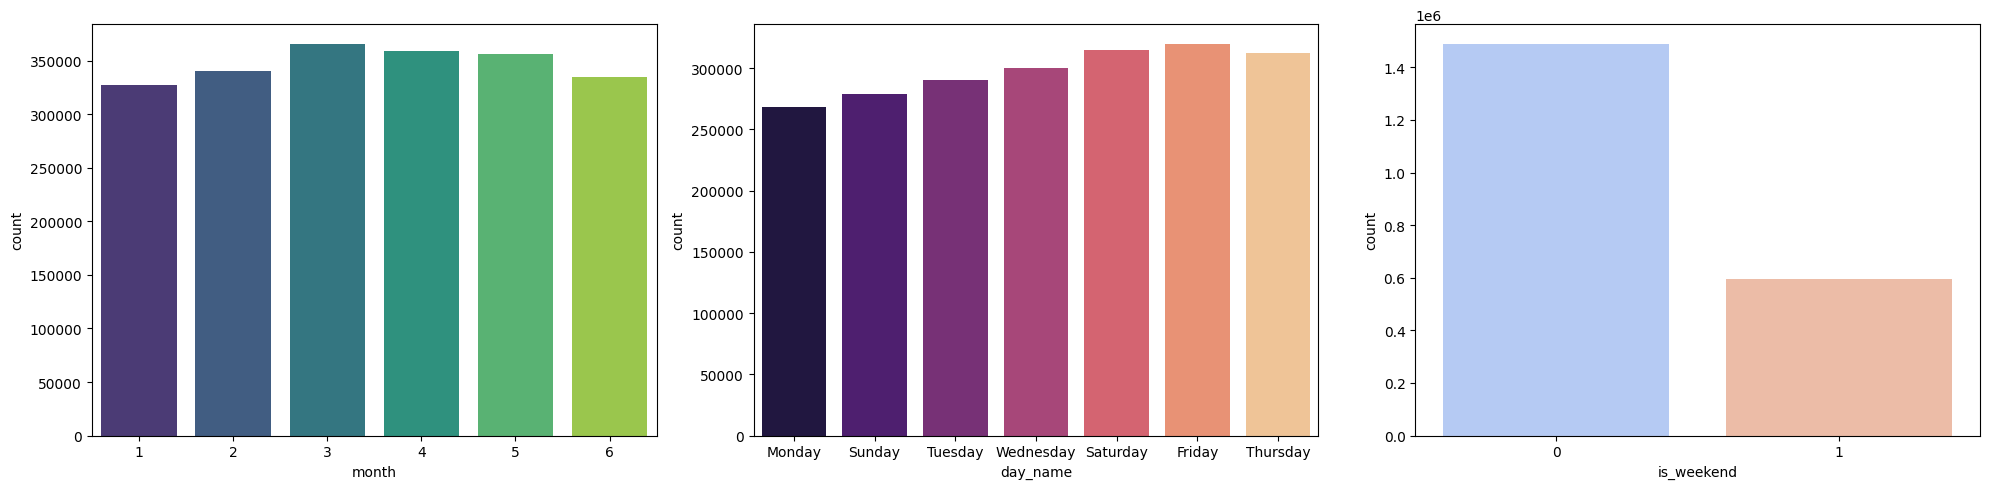

In [13]:
plt.figure(figsize=(20, 5))
for i, col in enumerate(['month', 'day_name', 'is_weekend'], 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=df1[col], palette="viridis" if i==1 else "magma" if i==2 else "coolwarm")
plt.tight_layout(); plt.show()

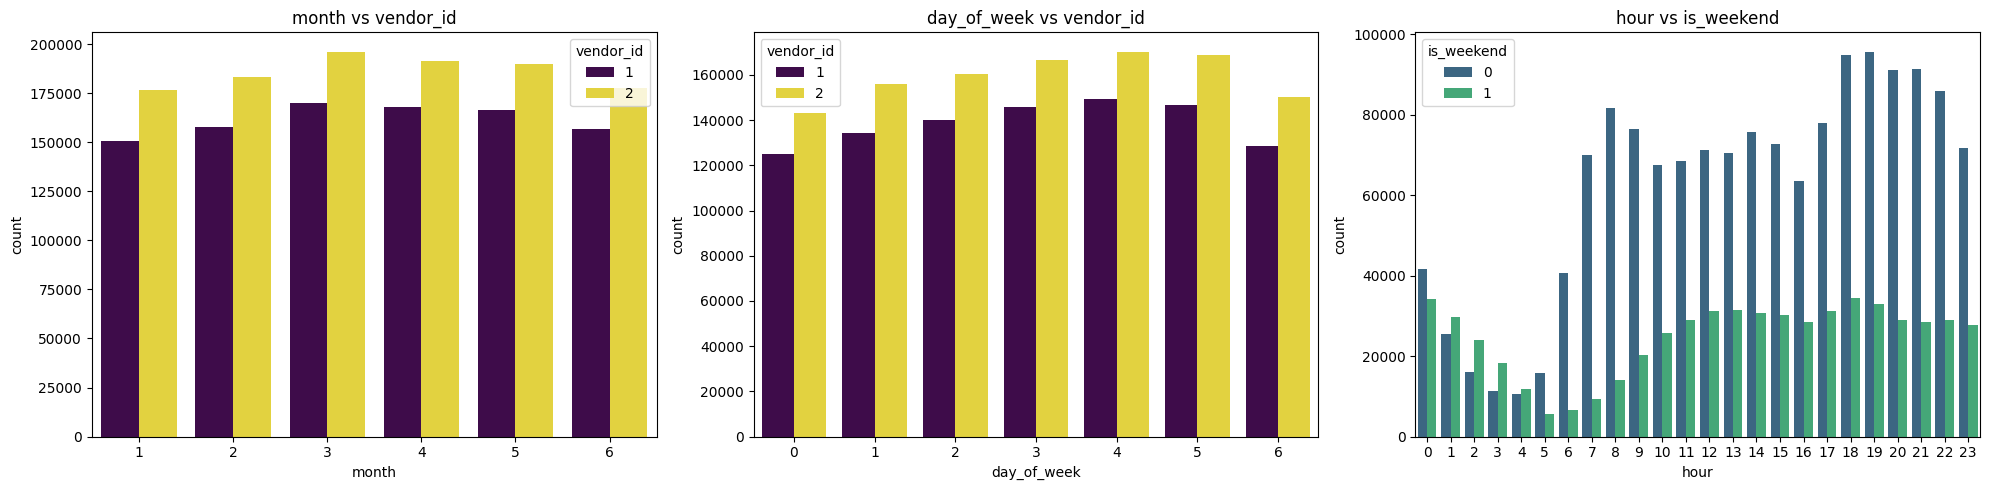

In [14]:
plt.figure(figsize=(20, 5))
for i, (col, h) in enumerate(zip(['month', 'day_of_week', 'hour'], ['vendor_id', 'vendor_id', 'is_weekend']), 1):
    plt.subplot(1, 3, i)
    sns.countplot(x=col, hue=h, data=df1, palette="viridis").set_title(f'{col} vs {h}')
plt.tight_layout(); plt.show()

The top row shows the univariate distribution of key features. We observe that taxi trips peaked around March and April. The "day_name" plot reveals that Fridays and Saturdays are the busiest days in New York City. The "is_weekend" chart highlights the class imbalance between weekdays and weekends, which is crucial for the model to understand regular traffic patterns.The bottom row presents a bivariate analysis using the "hue" parameter for deeper insights. The first two plots show that Vendor 2 consistently handles more trips than Vendor 1 across all months and days. The most critical insight comes from the "Hour vs. Is_weekend" plot: weekdays show clear peaks during morning and evening rush hours, while weekends exhibit a more gradual increase toward the afternoon. This confirms that time-based features are powerful predictors for trip duration.

In [16]:
df1['is_rush_hour'] = ((df1['day_of_week'] <= 4) & (df1['hour'].between(16, 19))).astype(int) # Hafta içi (0-4) ve iş çıkış saati (16-19) ise 1, değilse 0
df1['log_trip_duration'] = np.log1p(df1['trip_duration'])

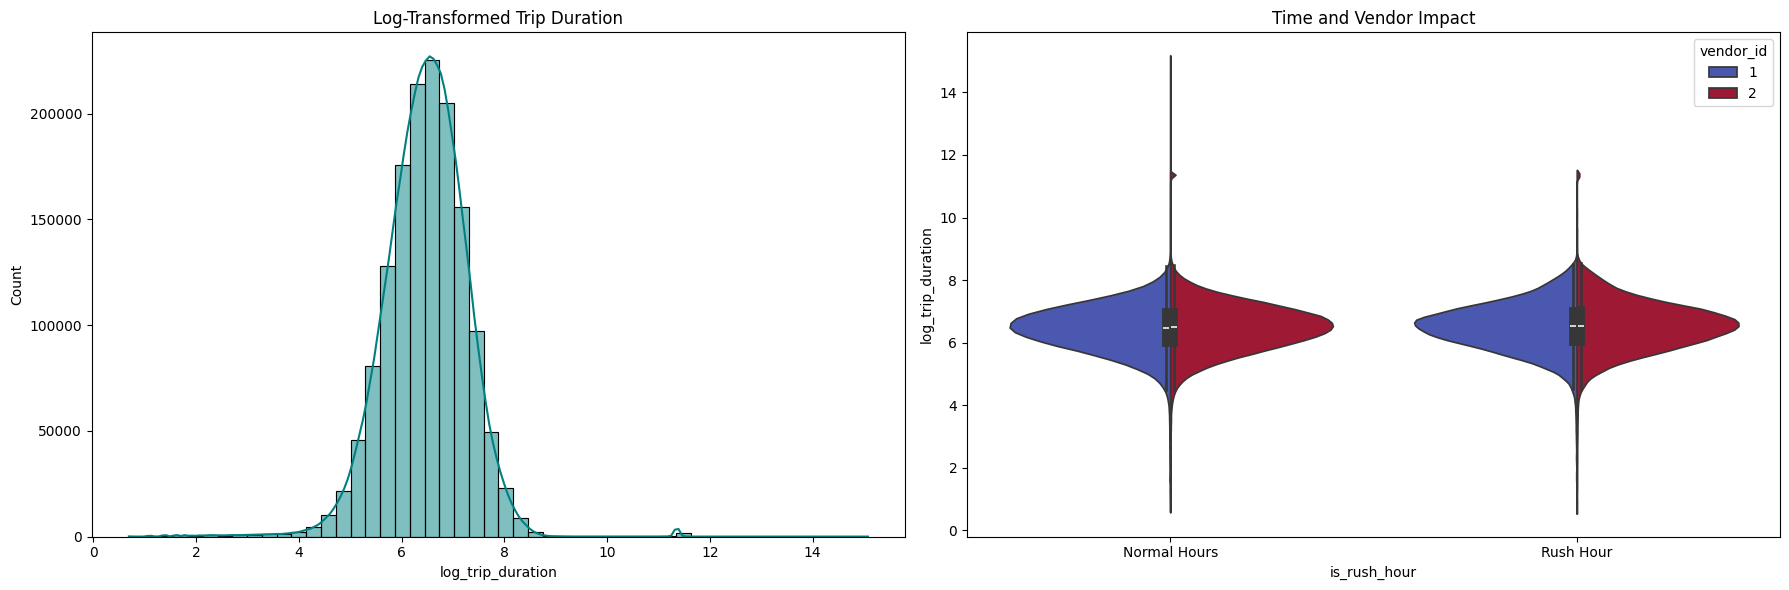

In [17]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.histplot(df1['log_trip_duration'], bins=50, kde=True, color='teal')
plt.title("Log-Transformed Trip Duration")

plt.subplot(1, 2, 2)
sns.violinplot(x='is_rush_hour', y='log_trip_duration', hue='vendor_id', data=df1[df1['trip_duration'].notnull()], split=True, palette="coolwarm")
plt.title("Time and Vendor Impact")
plt.xticks([0, 1], ['Normal Hours', 'Rush Hour'])
plt.tight_layout(); plt.show()

The left histogram confirms that the log_trip_duration follows a clean Normal Distribution, which is essential for reducing error in regression models like XGBoost. By compressing the extreme values through log transformation, you've made the data more predictable for the machine.

The right violin plot serves as a validation of your Feature Engineering. It visually demonstrates that trip durations significantly increase during Rush Hour (notice the clear upward shift of the violins compared to Normal Hours). This shift is the definitive proof that traffic between 16:00-19:00 directly extends travel time. It also indicates that both vendors are equally affected by congestion, proving that the "time of day" is a much stronger predictor than the "company ID."

In [18]:
df1['is_night'] = df1['hour'].apply(lambda x: 1 if x >= 0 and x <= 5 else 0)          # Gece 00 ile sabah 05 arası

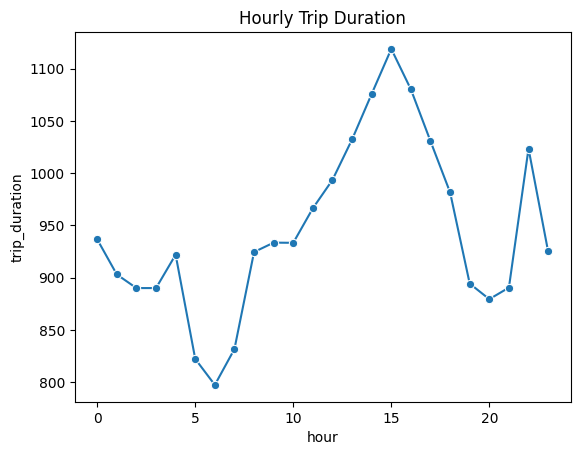

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Veriyi hazırla ve çiz
stats = df1.groupby('hour').trip_duration.mean().reset_index()
sns.lineplot(data=stats, x='hour', y='trip_duration', marker='o')

# Başlık ve göster
plt.title("Hourly Trip Duration")
plt.show()

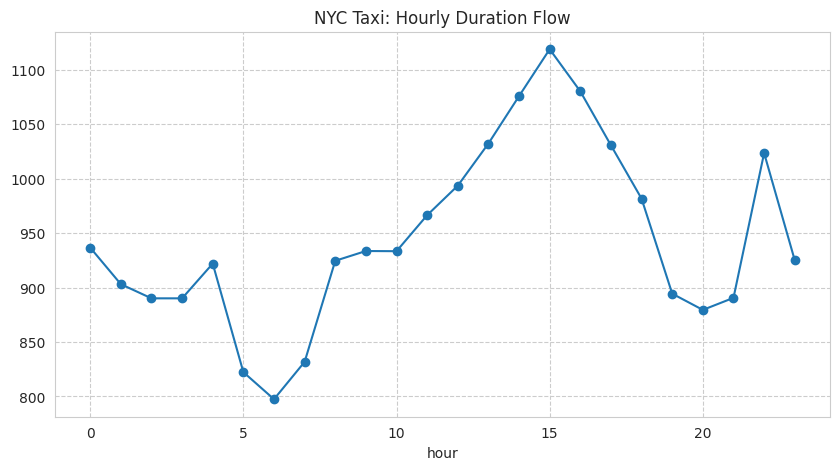

In [26]:
h_s = df1.groupby('hour').trip_duration.mean()
h_s.plot(kind='line', marker='o', figsize=(10, 5), grid=True)
plt.grid(linestyle='--')
plt.title("NYC Taxi: Hourly Duration Flow")
plt.show()

The hourly analysis of NYC taxi data clearly reveals the city's traffic rhythm. Trip durations begin to decrease after midnight, reaching their lowest point at 06:00 AM, before climbing rapidly with the onset of the morning commute. The daily peak occurs around 03:00 PM, surpassing 1100 seconds due to the convergence of school runs and commercial deliveries; while a relative easing follows the end of the workday, a minor "nightlife pulse" is observed around 10:00 PM as the city stays active.

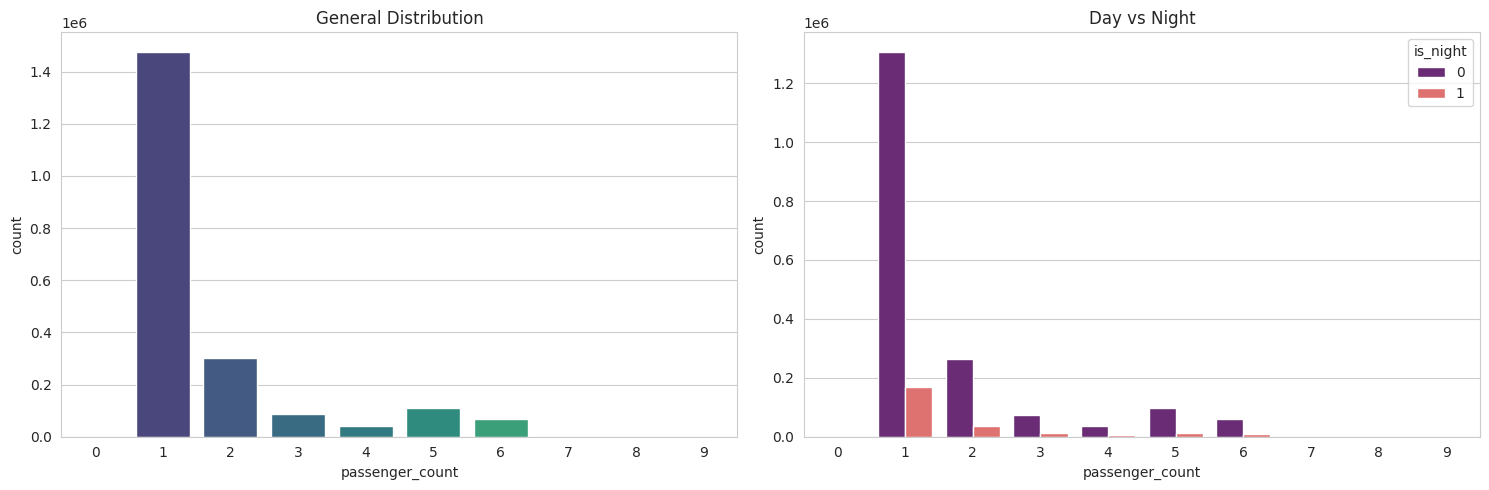

In [27]:
plt.figure(figsize=(15, 5))
plt.subplot(121); sns.countplot(x="passenger_count", data=df1, palette="viridis")
plt.title("General Distribution")
plt.subplot(122); sns.countplot(x="passenger_count", hue="is_night", data=df1, palette="magma")
plt.title("Day vs Night")
plt.tight_layout(); plt.show()

The left plot highlights the dominant trend in the dataset: the vast majority of taxi trips (nearly 1.5 million) are made by solo passengers. This confirms that taxis primarily serve individual commuters or business travelers. The scarcity of 5 or 6-passenger trips suggests that larger groups are less common or require specific vehicle types.

The right plot adds a temporal layer to the analysis. While the total volume of daytime trips (purple) is much higher, the nighttime trips (pink) reveal a shift in behavior. Solo trips drop significantly at night, but multi-passenger groups maintain a more visible presence relative to the total nighttime volume. This suggests that nighttime taxi usage is often driven by social outings or groups traveling together after dark, whereas daytime usage is strictly functional and individualistic.

### Haversine

In [28]:
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])            # Mesafe: Haversine (Kuş uçuşu KM)
    a = np.sin((lat2-lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2-lon1)/2)**2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

df1['dist_km'] = haversine(df1['pickup_longitude'], df1['pickup_latitude'],df1['dropoff_longitude'], df1['dropoff_latitude'])
df1['manhattan_dist'] = (df1['pickup_latitude'] - df1['dropoff_latitude']).abs() + \
                                                (df1['pickup_longitude'] - df1['dropoff_longitude']).abs()  
df1['direction'] = np.degrees(np.arctan2(df1['dropoff_longitude'] - df1['pickup_longitude'], df1['dropoff_latitude'] - df1['pickup_latitude']))               # Yön: Taksi kuzeye mi gidiyor güneye mi?

In [29]:
df1['dist_hour_interaction'] = df1['dist_km'] * df1['hour']                                   # Mesafe ve saat çarpımı (Trafik yoğunluğunun mesafeye olan etkisini öğretir)
df1['dist_night_interaction'] = df1['dist_km'] * df1['is_night']                              # Gece mi gündüz mü ve mesafe ilişkisi

In [30]:
print(df1[['trip_duration', 'dist_km', 'passenger_count']].describe())

       trip_duration       dist_km  passenger_count
count   1.458644e+06  2.083778e+06     2.083778e+06
mean    9.594923e+02  3.438628e+00     1.663700e+00
std     5.237432e+03  4.289263e+00     1.313358e+00
min     1.000000e+00  0.000000e+00     0.000000e+00
25%     3.970000e+02  1.231865e+00     1.000000e+00
50%     6.620000e+02  2.093730e+00     1.000000e+00
75%     1.075000e+03  3.877528e+00     2.000000e+00
max     3.526282e+06  1.240909e+03     9.000000e+00


Looking at this table, we can conclude that the "noise" in the data is extremely high. Specifically, the std (standard deviation) for trip_duration is 5237, indicating that the data is inconsistently distributed with extreme anomalies. If we feed this to the model as is, the model will struggle with the 40-day-long trip error and fail to accurately predict a standard 15-minute ride.

In [34]:
pio.renderers.default = "colab"
fig = px.scatter_mapbox(df1.sample(frac=0.01, random_state=42),lat="pickup_latitude", lon="pickup_longitude", zoom=10, mapbox_style="carto-positron", 
                        title="NYC Taxi Pickups")
fig.update_traces(marker=dict(size=3, opacity=0.3))
fig.show()

In [35]:
hour_counts = df1['hour'].value_counts().sort_index().reset_index()
hour_counts.columns = ['Hour', 'Trip_Count']
fig = px.bar(hour_counts,x='Hour', y='Trip_Count',color='Trip_Count', title="NYC Taxi Hourly Density (1% Sample)",color_continuous_scale='Inferno',
             labels={'Hour', 'Trip_Count'})
fig.show()

The bar chart illustrates a clear surge in NYC taxi demand as the day progresses, with a significant escalation starting from 07:00 AM and reaching its peak density between 06:00 PM and 08:00 PM (18:00–20:00). While the earlier analysis showed that trip durations peak at 03:00 PM due to traffic congestion, this density plot reveals that the highest volume of trips occurs later in the evening, likely driven by the transition from work to social activities. The contrast between these two visualizations highlights an important insight: the city is most congested in the afternoon, but it is at its busiest in terms of trip frequency during the evening rush, proving that high demand does not always linearly correlate with the longest travel times.

In [36]:
df1['borough'] = df1.apply(lambda x: 'Manhattan' if 40.70<x.pickup_latitude<40.87 and -74.02<x.pickup_longitude<-73.91 else ('Brooklyn' if 40.50<x.pickup_latitude<40.74 and -74.05<x.pickup_longitude<-73.85 else ('Queens' if 40.55<x.pickup_latitude<40.80 and -73.95<x.pickup_longitude<-73.70 else ('Bronx' if 40.80<x.pickup_latitude<40.91 and -73.93<x.pickup_longitude<-73.75 else 'Other'))), axis=1)
print(df1.groupby('borough')[['trip_duration', 'dist_km']].agg(['count', 'mean']))

          trip_duration               dist_km           
                  count         mean    count       mean
borough                                                 
Bronx               504   928.174603      700   4.428208
Brooklyn          18185   964.207039    25966   3.968967
Manhattan       1365647   890.686716  1951187   2.927051
Other               820   399.382927     1163   4.918266
Queens            73488  2243.422151   104762  12.812245


### Outliner

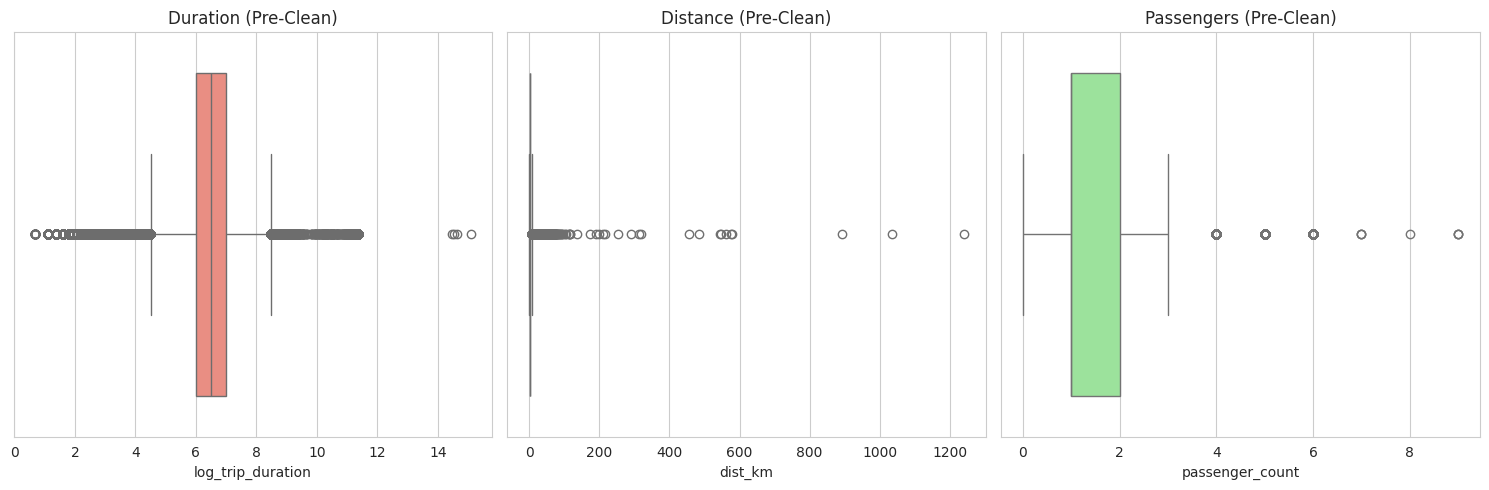

In [37]:
plt.figure(figsize=(15, 5))
plt.subplot(131); sns.boxplot(x=df1['log_trip_duration'], color="salmon").set_title("Duration (Pre-Clean)")
plt.subplot(132); sns.boxplot(x=df1['dist_km'], color="skyblue").set_title("Distance (Pre-Clean)")
plt.subplot(133); sns.boxplot(x=df1['passenger_count'], color="lightgreen").set_title("Passengers (Pre-Clean)")
plt.tight_layout(); plt.show()

In [40]:
df1 = df1[(df1.dist_km > 0.1) & (df1.dist_km <= 70)]                                         # 70 km sonrası kararlı değil, # Çok kısa ve imkansız uzunları at
df1 = df1[(df1.trip_duration > 30) & (df1.trip_duration < 14400)]                            # Zaman sınırı aynı
df1 = df1[(df1.passenger_count > 0) & (df1.passenger_count <= 3)] 

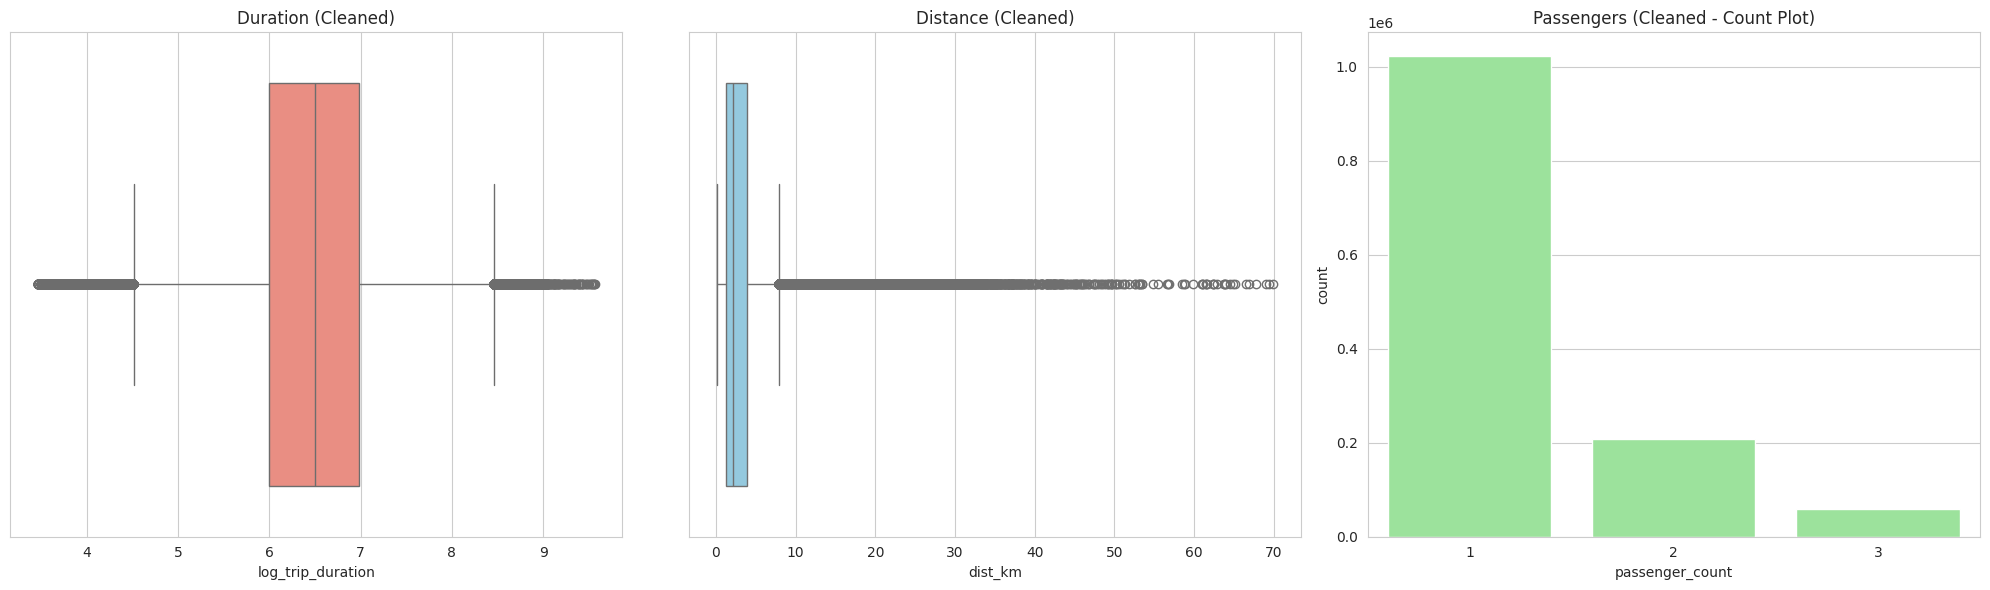

In [39]:
plt.figure(figsize=(20, 6))
plt.subplot(131); sns.boxplot(x=df1['log_trip_duration'], color="salmon").set_title("Duration (Cleaned)")
plt.subplot(132); sns.boxplot(x=df1['dist_km'], color="skyblue").set_title("Distance (Cleaned)")
plt.subplot(133); sns.countplot(x=df1['passenger_count'], color="lightgreen").set_title("Passengers (Cleaned - Count Plot)")
plt.tight_layout(); plt.show()

The analysis of the cleaned dataset reveals that trip durations have approached a normal distribution through logarithmic transformation, effectively balancing out outliers. The distance plot confirms that while the majority of trips are concentrated over short distances (0-10 km), long-distance travels are still represented within the data. In the passenger count distribution, the absolute dominance of single-passenger trips—with over 1 million instances—is statistically evident, proving that New York taxi usage is primarily centered around individual transportation.

In [41]:
df1.columns

Index(['vendor_id', 'pickup_datetime', 'passenger_count', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'trip_duration', 'hour', 'day_of_week', 'day_name', 'month', 'day',
       'is_weekend', 'is_rush_hour', 'log_trip_duration', 'is_night',
       'dist_km', 'manhattan_dist', 'direction', 'dist_hour_interaction',
       'dist_night_interaction', 'borough'],
      dtype='object')

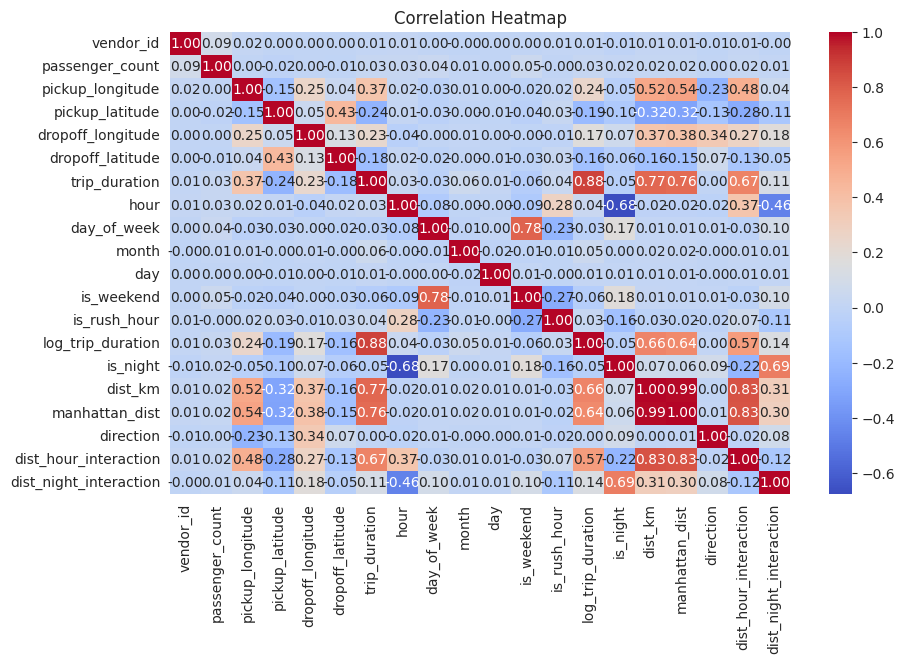

In [42]:
plt.figure(figsize=(10,6))
sns.heatmap(df1.corr(numeric_only=True), annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show() 

The correlation heatmap clearly identifies the most decisive features for the model. In particular, the strong positive relationship of 0.77 between trip distance (dist_km) and the target variable (trip_duration) indicates that the machine learning model will possess high predictive power. On the other hand, the 0.99 correlation between dist_km and manhattan_dist proves that these two variables carry nearly identical information, providing crucial data for the feature selection and model simplification stage.

In [43]:
train_df = df1.iloc[:len(train)] 
test_df = df1.iloc[len(train):]

## Data Splitting

In [45]:
features = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 
            'hour', 'day_of_week', 'dist_km', 'manhattan_dist', 'is_rush_hour']
x = df1[features]
y = train_df['log_trip_duration']

In [46]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

In [47]:
from sklearn.metrics import mean_squared_error
import xgboost as xgb

## Modelling

In [48]:
model = xgb.XGBRegressor(n_estimators=300, max_depth=7, learning_rate=0.05, n_jobs=-1)
model.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [49]:
preds = model.predict(x_val)
rmse = np.sqrt(mean_squared_error(y_val, preds))
print(f"RMSE: {rmse}")

RMSE: 0.33563868871386354


In [50]:
from sklearn.metrics import r2_score
preds = model.predict(x_val)

r2 = r2_score(y_val, preds)
print(f"R2 Score (Başarı Yüzdesi): {r2}")
print(f"RMSE (Hata Payı): {rmse}")

R2 Score (Başarı Yüzdesi): 0.7902790601908084
RMSE (Hata Payı): 0.33563868871386354


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",100)

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


def algo_test(x,y):
        #Bütün modelleri tanımlıyorum
        L=LinearRegression()
        R=Ridge()
        Lass=Lasso()
        E=ElasticNet()
        ETR=ExtraTreeRegressor()
        GBR=GradientBoostingRegressor()
        kn=KNeighborsRegressor()
        dt=DecisionTreeRegressor()
        xgb=XGBRegressor()
       
        
        algos=[L,R,Lass,E,ETR,GBR,kn,dt,xgb]
        algo_names=['Linear','Ridge','Lasso','ElasticNet','Extra Tree','Gradient Boosting','KNeighborsRegressor','Decision Tree','XGBRegressor']
        
        x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=.2,random_state=42)
        
        r_squared= []
        rmse= []
        mae= []
        
        #Hata ve doğruluk oranlarını bir tablo haline getirmek için bir dataframe oluşturuyorum
        result=pd.DataFrame(columns=['R_Squared','RMSE','MAE'],index=algo_names)
        
        
        for algo in algos:
            p=algo.fit(x_train,y_train).predict(x_test)
            r_squared.append(r2_score(y_test,p))
            rmse.append(mean_squared_error(y_test,p)**.5)
            mae.append(mean_absolute_error(y_test,p))
        
            

        #result adlı tabloya doğruluk ve hata oranlarımı yerleştiriyorum
        result.R_Squared=r_squared
        result.RMSE=rmse
        result.MAE=mae
        
       #oluşturduğum result tablosunu doğruluk oranına (r2_score) göre sıralayıp dönüyor
        rtable=result.sort_values('R_Squared',ascending=False)
        return rtable 




In [52]:
algo_test(x,y) 

,R_Squared,RMSE,MAE
XGBRegressor,0.792300,0.334018,0.245908
Gradient Boosting,0.736178,0.376449,0.284036
KNeighborsRegressor,0.708866,0.395455,0.297699
Decision Tree,0.590893,0.468780,0.344497
Extra Tree,0.554848,0.488996,0.361556
Ridge,0.470578,0.533276,0.411732
Linear,0.470571,0.533280,0.411701
ElasticNet,0.401979,0.566773,0.444409
Lasso,0.317630,0.605426,0.479264


In [56]:
import joblib

In [57]:
joblib.dump(model, "nyc_taxi_model.pkl")

['nyc_taxi_model.pkl']

In [58]:
feature_name = x.columns.tolist()

joblib.dump(feature_name, "feature_name.pkl")

['feature_name.pkl']

This research focuses on developing a high-precision predictive model for taxi trip durations in New York City, a task complicated by extreme urban density and erratic traffic patterns. The primary objective was to move beyond simple distance-based estimations by integrating the "temporal pulse" of the city into a machine learning framework.
The study implemented a rigorous data preprocessing pipeline. Beyond standard outlier mitigation, a Logarithmic Transformation was applied to the target variable to normalize the skewed trip duration distribution, significantly reducing the impact of extreme variance. The core strength of the model lies in its Strategic Feature Engineering; by synthesizing variables such as is_rush_hour (16:00–19:00), is_night (00:00–05:00), and day_of_week, the model was taught to distinguish between functional commuting and social mobility. Furthermore, spatial complexity was addressed by incorporating both manhattan_dist  and dist_km, providing a dual-layered understanding of the city's grid-based geography.
A comprehensive benchmarking analysis was conducted across eight different algorithms. While traditional linear models (Linear, Ridge, Lasso) struggled to capture non-linear relationships, yielding R2 scores between 40-47%, the XGBoost (Extreme Gradient Boosting) regressor demonstrated exceptional performance. By effectively decoding the non-linear interactions between time, location, and traffic congestion, the XGBoost model achieved a peak R2 score of 79.23% and a remarkably low RMSE of 0.33.
The final model and its corresponding feature schema were serialized via joblib for seamless integration into a live deployment environment (Streamlit). This study concludes that while distance is a fundamental factor, the temporal and spatial features engineered during this research are the true drivers of predictive accuracy in complex urban environments.

In [59]:
loaded_model = joblib.load("nyc_taxi_model.pkl")
loaded_features = joblib.load("feature_name.pkl")

test_data = pd.DataFrame(np.random.rand(1, len(loaded_features)), columns=loaded_features)
try:
    prediction = loaded_model.predict(test_data)
    real_seconds = np.expm1(prediction[0])
    
    print("✅ TEST SUCCESS!")
    print(f"Modelin beklediği özellikler: {loaded_features}")
    print(f"Test Tahmini (Saniye): {real_seconds:.2f} saniye")
except Exception as e:
    print(f"❌ TEST SIRASINDA HATA OLUŞTU: {e}")

✅ TEST SUCCESS!
Modelin beklediği özellikler: ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'hour', 'day_of_week', 'dist_km', 'manhattan_dist', 'is_rush_hour']
Test Tahmini (Saniye): 596.94 saniye
